In [1]:
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import torch.optim as optim

bs = 10
crop_size = 224

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [3]:
train_transform = transforms.Compose([ 
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(crop_size, scale = (0.98, 1.0)),
    transforms. RandomHorizontalFlip(),
    transforms. RandomVerticalFlip(),
    transforms. ToTensor(),
    transforms.Normalize (mean =[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
    
test_transform = transforms.Compose([
    transforms.Resize(230),
    transforms.CenterCrop (224),
    transforms.ToTensor(),
    transforms. Normalize (mean =[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
    
train_set = datasets. ImageFolder("/kaggle/input/arabica-beans/arabica_beans/80-20/train", transform=train_transform)
trainloader = DataLoader (train_set, batch_size=bs, shuffle=True, num_workers=4)

test_set = datasets. ImageFolder("/kaggle/input/arabica-beans/arabica_beans/80-20/test", transform=test_transform)
testloader = DataLoader (test_set, batch_size=bs, shuffle=True)

from torchvision.models import mobilenet_v2

class CustomMobileNetV2(nn.Module): 
    def __init__(self, output_size): 
        super().__init__()
        self.mnet = mobilenet_v2 (pretrained=True)
        self.freeze()
        self.mnet.classifier = nn.Sequential( 
            nn.Linear(1280, output_size),
            nn.LogSoftmax()
        )
        
    def forward(self, x):
        return self.mnet(x)
    
    def freeze(self):
        for param in self.mnet.parameters(): 
            param.requires_grad= False
    
    def unfreeze(self):
        for param in self.mnet.parameters():
            param.requires_grad= True

In [4]:
output_size = 6 
model = CustomMobileNetV2(output_size).to(device)
criterion = nn.NLLLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 90.3MB/s]


In [5]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

def loop_fn(mode, dataset, dataloader, model, criterion, optimizer, device): 
    if mode == "train":
        model.train()
    elif mode == "test":
        model.eval()
    cost = correct = 0
    for feature, target in tqdm(dataloader, desc=mode.title()):
        feature, target = feature.to(device), target.to(device)
        output = model(feature) #Feedforward
        loss = criterion(output, target) #hitung loss

        if mode == "train":
            loss.backward() #backprop 
            optimizer.step() #update weight 
            optimizer.zero_grad()

        cost += loss.item() * feature.shape[0]
        correct += (output.argmax(1) == target).sum().item()
    cost = cost / len(dataset)
    acc = correct / len(dataset)
    return cost, acc

In [6]:
num_epochs = 50

for epoch in range(num_epochs):
    train_cost, train_score = loop_fn("train", train_set, trainloader, model, criterion, optimizer, device)
    with torch.no_grad():
        test_cost, test_score = loop_fn("test", test_set, testloader, model, criterion, optimizer, device)

    # Logging
    print(f"Epoch {epoch + 1}/{num_epochs}:")
    print(f"  Train Loss: {train_cost:.4f} | Train Accuracy: {train_score:.4f}")
    print(f"  Test Loss: {test_cost:.4f} | Test Accuracy: {test_score:.4f}")

    # Save history
    train_losses.append(train_cost)
    train_accuracies.append(train_score)
    test_losses.append(test_cost)
    test_accuracies.append(test_score)
    
    if epoch + 1 == num_epochs:
        print("Training finished.")

Train:   0%|          | 0/96 [00:00<?, ?it/s]

/opt/conda/lib/python3.10/site-packages/torch/nn/modules/module.py:1518: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Test:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/50:
  Train Loss: 1.3017 | Train Accuracy: 0.4490
  Test Loss: 0.9655 | Test Accuracy: 0.5708


Train:   0%|          | 0/96 [00:00<?, ?it/s]

...

Test:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 49/50:
  Train Loss: 0.6039 | Train Accuracy: 0.7458
  Test Loss: 0.6596 | Test Accuracy: 0.7167


Train:   0%|          | 0/96 [00:00<?, ?it/s]

Test:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 50/50:
  Train Loss: 0.5843 | Train Accuracy: 0.7781
  Test Loss: 0.6755 | Test Accuracy: 0.7458
Training finished.


In [7]:
model.unfreeze()
optimizer = optim.AdamW(model.parameters(), lr=1e-5)

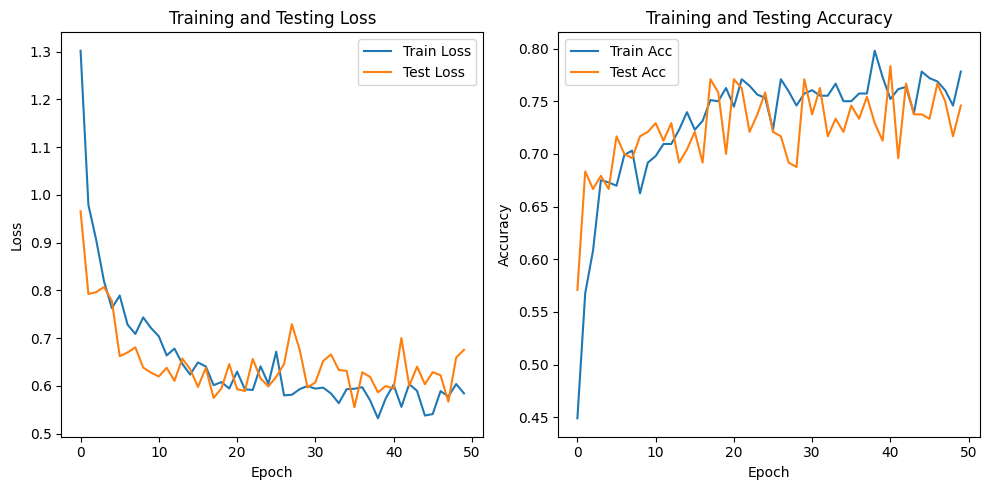

In [8]:
# Plot the training and testing loss and accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(test_accuracies, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy')
plt.legend()

plt.tight_layout()

# Save the plot
plt.savefig('mobilenetv2(8020).png')

plt.show()

In [9]:
# Define the path where you want to save the model
save_path = "mobilenetv2(8020).pth"

# Save the entire model
torch.save(model, save_path)

# Or, save only the model state dictionary
torch.save(model.state_dict(), save_path)

print("Model saved successfully.")


Model saved successfully.


In [10]:
torch.save(model.state_dict(), 'mobilenetv2(8020)weight.pth')

In [11]:
# Excel Record

import pandas as pd
from pandas import ExcelWriter

data = {
    'Train Loss': train_losses,
    'Train Acc': train_accuracies,
    'Test Loss': test_losses,
    'Test Acc': test_accuracies
}

df = pd.DataFrame(data)

with ExcelWriter('mobilenetv2(8020).xlsx') as writer:
    df.to_excel(writer, sheet_name='All Data')
    train_loss_df = pd.DataFrame({'Epoch': train_losses, 'Train Loss': train_losses})
    train_loss_df.to_excel(writer, sheet_name='Training Loss')
    test_loss_df = pd.DataFrame({'Epoch': test_losses, 'Test Loss': test_losses})
    test_loss_df.to_excel(writer, sheet_name='Testing Loss')
    train_acc_df = pd.DataFrame({'Epoch': train_accuracies, 'Train Acc': train_accuracies})
    train_acc_df.to_excel(writer, sheet_name='Training Accuracy')
    test_acc_df = pd.DataFrame({'Epoch': test_accuracies, 'Test Acc': test_accuracies})
    test_acc_df.to_excel(writer, sheet_name='Testing Accuracy')